# Dataset Preparation

- input: curated briefsummary
- output: pd.series of ase objects pr pymatgen objects


In [1]:
from Tools.DatasetTools.Commoms import *
sys.path.insert(0, '/home/storage/fortimtb/CuadernoTrabajo/bopfoxfeaturizer/')
from BopFoxFeaturizer.Featurizer import Featurizer
from Tools.DatasetTools.Tools import need_to_update
from Tools.DatasetTools.SublatticeSorter import *
from pymatgen.io.ase import AseAtomsAdaptor

# options 

In [2]:
dataset = 'Fe-Mo'  # 'Cr-Co-W' 'Fe-Mo'
case = 'POSCAR-initial'  # 'POSCAR-relaxed']
rescale_by_atoms = True #  False]
subcase = 'rescaled' #  'noscaled' ] 
Force = True
CuratedBS = os.path.join(dataset,'FurtherCuratedParsedBriefSummary.pkl')

In [3]:
components = dataset.replace('-','')

In [4]:
BS = pd.read_pickle(CuratedBS)

Features = Featurizer(BS)

chech that the chemistry resetting is correct!

# Sort Poscar files

In [5]:
searchs = 'POSCAR.initial'
files = get_file_paths(dataset, searchs)
atomsobjectslocation = os.path.join(dataset,'Atomsobjects')
sublatticesortersfile = os.path.join(atomsobjectslocation, 'SORTERS.pkl')
sublatticetagfile = os.path.join(atomsobjectslocation, 'SUBLATICETAGS.pkl')

In [6]:
if need_to_update(sublatticesortersfile) or need_to_update(sublatticetagfile):
    pdb.set_trace()
    SORTERS, SUBLATICETAGS = get_all_sorters_and_tags(dataset, files)
    SORTERS.to_pickle(sublatticesortersfile)
    SUBLATICETAGS.to_pickle(sublatticetagfile)
else:
    SORTERS = pd.read_pickle(sublatticesortersfile)
    SUBLATICETAGS = pd.read_pickle(sublatticetagfile)

# Now I have to pick the atoms objects

In [7]:
#for thiscase, (thisrescale, thissubcase) in product(case, zip(rescale_by_atoms, subcase)):
database = f'{dataset}/**/{case}'
AtomsFile = os.path.join(atomsobjectslocation,f'{components}-{case}-{subcase}-AtomsObjects.pkl')

In [8]:
if not need_to_update(AtomsFile):  #os.path.exists(AtomsFile) and not Force:
    Atoms_Objects = pd.read_pickle(AtomsFile)
else:
    Atoms_Objects, CantMake_Atoms_Object = Features.get_atoms_object(database=database,rescale_by_atoms=True, reset_chemistry=True,file_filter = 'initial$')
    Atoms_Objects.to_pickle(AtomsFile)
    Atoms_Objects.dropna(inplace=True)
pymatgenfile = AtomsFile.replace('AtomsObjects','PymatgenStructures')
Pymatgen_Structures = Atoms_Objects.copy()
if not need_to_update(pymatgenfile):
    Pymatgen_Structures = pd.read_pickle(pymatgenfile)
else:
    Pymatgen_Structures = Atoms_Objects['atoms'].apply(AseAtomsAdaptor.get_structure)
    Pymatgen_Structures['file'] = Atoms_Objects['file']
    Pymatgen_Structures.to_pickle(pymatgenfile)

In [9]:
Atoms_Objects.atoms.isna().sum()

0

In [10]:
allindex = Atoms_Objects.index.intersection(BS.index)

In [11]:
Atoms_Objects = Atoms_Objects.loc[allindex]

In [12]:
Atoms_Objects.to_pickle(AtomsFile)

In [13]:
accomodatewrap = Atoms_Objects.atoms.map(lambda a: a.wrap(pretty_translation=True))

In [14]:
difference = BS.index.difference(Atoms_Objects.index)

In [15]:
difference

Index([], dtype='object')

#  visualization of some structures

In [16]:
plt.rc('axes.spines', bottom=False, top=False, right=False, left=False)

In [17]:
from ase.visualize.plot import plot_atoms

In [18]:
Atoms_Objects

,atoms,file
Fe_pv8.A15.FM,"(Atom('Fe', [0.0, 0.0, 0.0], index=0), Atom('F...",[Fe-Mo/Fe_pv/POSCAR-initial/A15.FM/relax/xc=PB...
Fe_pv12.C14.FM,"(Atom('Fe', [0.39005643922762884, 0.6755972555...",[Fe-Mo/Fe_pv/POSCAR-initial/C14.FM/relax/xc=PB...
Fe_pv17Mo_sv12.chi-AAAB.FM,"(Atom('Fe', [1.744684287558098, 1.744684287558...",[Fe-Mo/Fe_pv-Mo_sv/POSCAR-initial/chi-AAAB.FM/...
Fe_pv24Mo_sv5.chi-BBAA.FM,"(Atom('Fe', [0.46636968511679816, 0.4663696851...",[Fe-Mo/Fe_pv-Mo_sv/POSCAR-initial/chi-BBAA.FM/...
Fe_pv25Mo_sv4.chi-ABAA.FM,"(Atom('Fe', [1.7274873476817147, 1.72748734768...",[Fe-Mo/Fe_pv-Mo_sv/POSCAR-initial/chi-ABAA.FM/...
...,...,...
Fe_pv25Mo_sv4.chi-ABAA.NM,"(Atom('Fe', [1.7274873476817147, 1.72748734768...",[Fe-Mo/Fe_pv-Mo_sv/POSCAR-initial/chi-ABAA/rel...
Fe_pv16Mo_sv8.C36-BBAAA.NM,"(Atom('Fe', [2.7086505008612454, 0.67995870064...",[Fe-Mo/Fe_pv-Mo_sv/POSCAR-initial/C36-BBAAA/re...
Fe_pv8Mo_sv4.C14-BAA.NM,"(Atom('Fe', [0.0, 0.0, 5.733713754107139], ind...",[Fe-Mo/Fe_pv-Mo_sv/POSCAR-initial/C14-BAA/rela...
Fe_pv4.fcc-cubic.NM,"(Atom('Fe', [0.0, 1.7912144064990119, 1.791214...",[Fe-Mo/Fe_pv/POSCAR-initial/fcc-cubic/relax/xc...


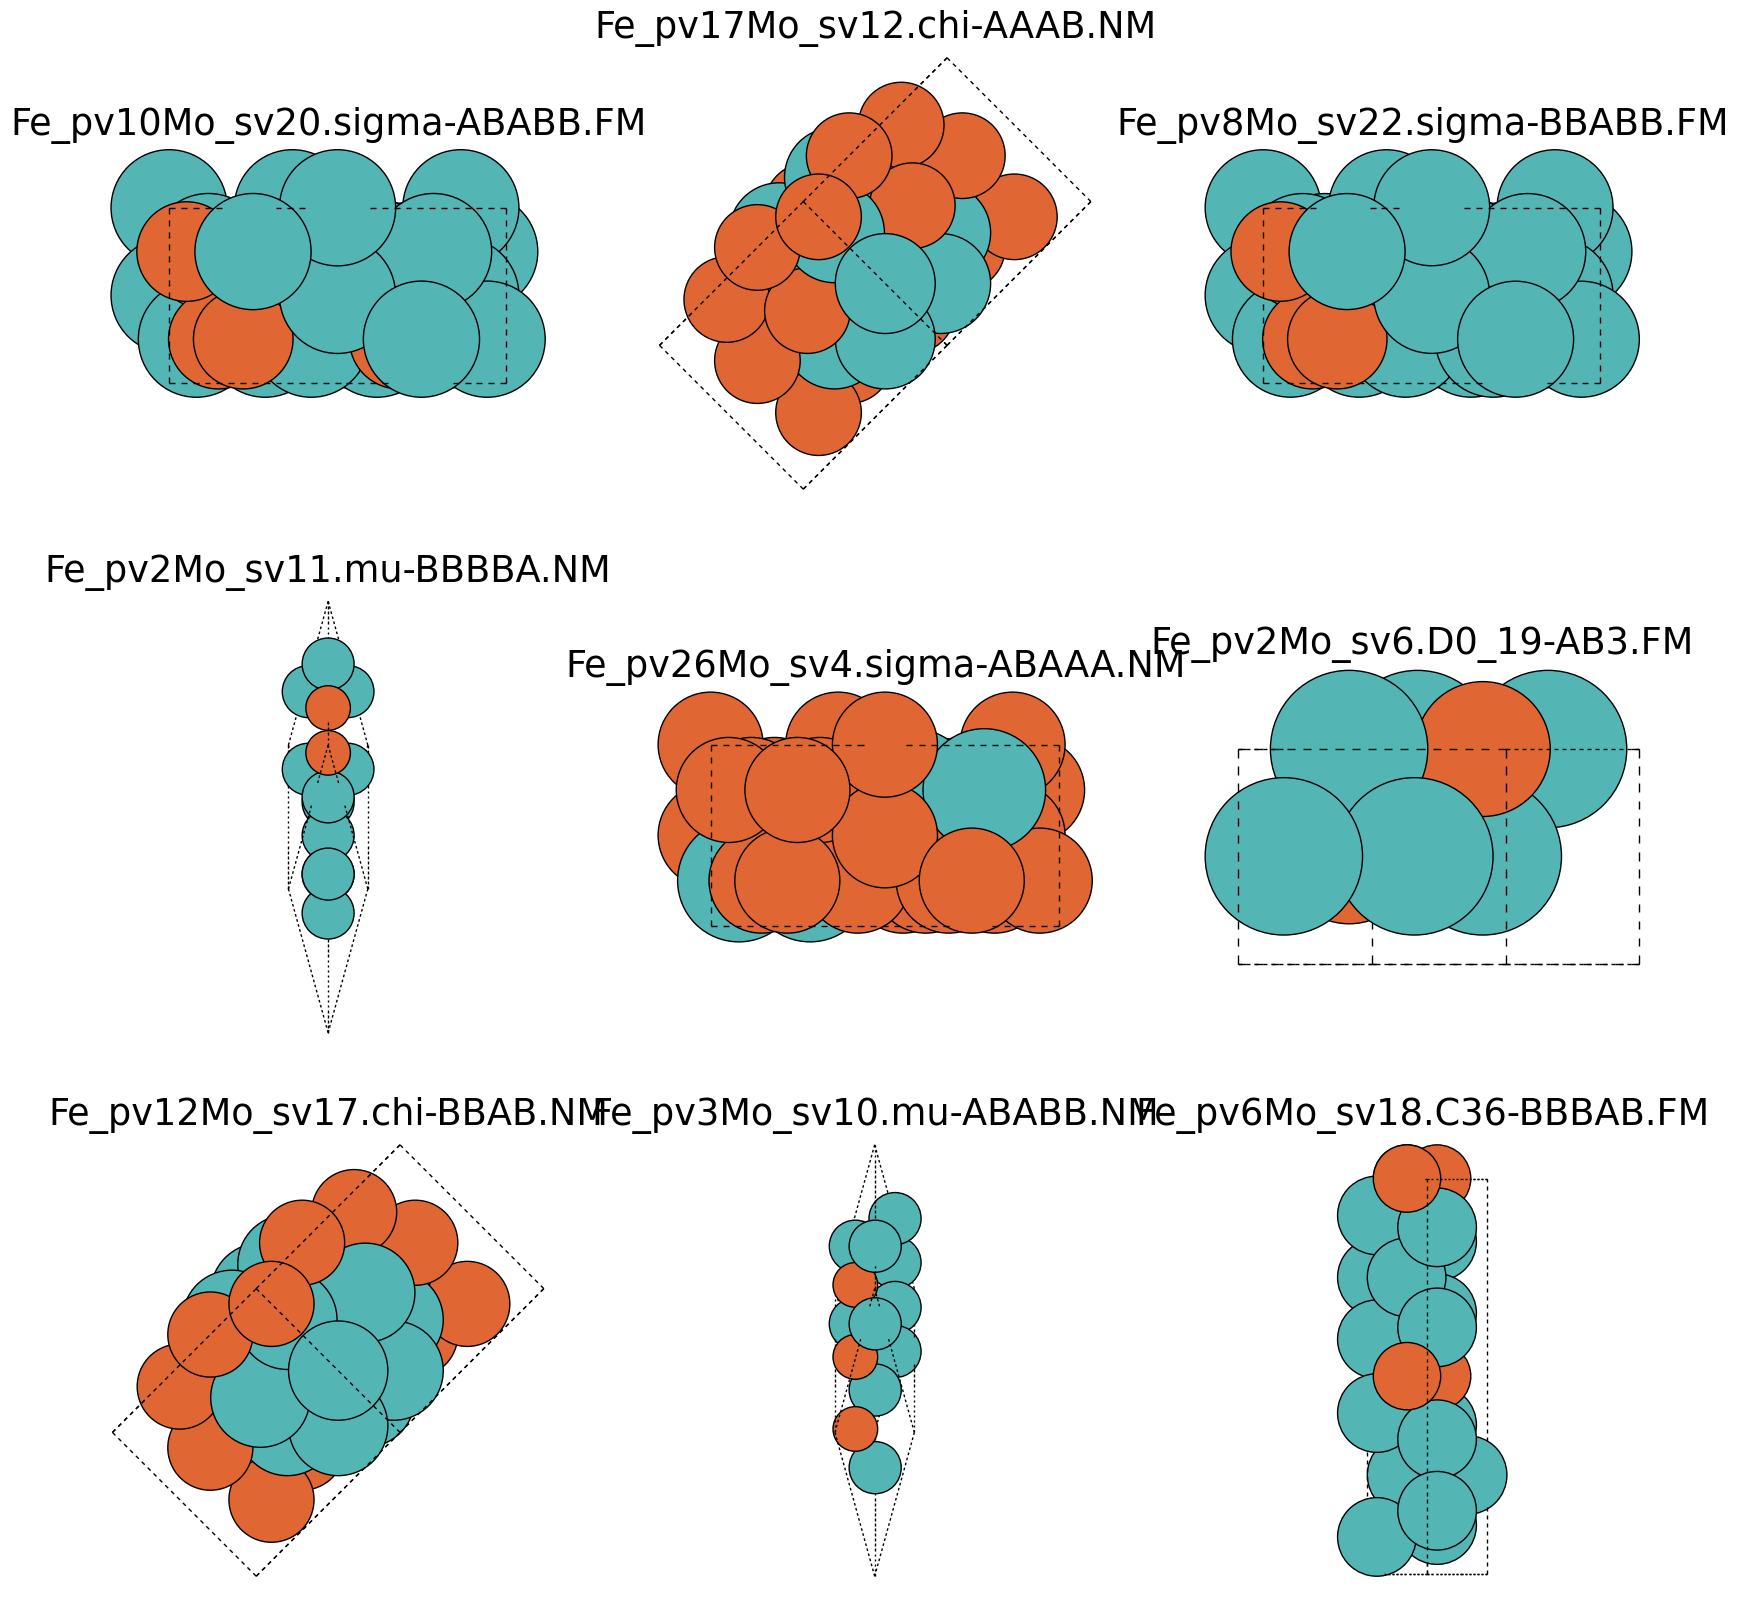

In [19]:
atoms_samples = Atoms_Objects.atoms.sample(n=9)
fig, ax = plt.subplots(3,3, figsize = (20,20))
ax = ax.flatten()
for thisax, (thisname, thisatoms) in  zip(ax, atoms_samples.iteritems()):
    plot_atoms(thisatoms, ax=thisax, rotation = '90x')
#    [spine.set_visible(False) for spine in thisax.spines.values()]
    thisax.set_xticks([])
    thisax.set_yticks([])
    thisax.set_title(thisname)

In [20]:
somesigmas = Atoms_Objects.atoms[Atoms_Objects.index.str.contains('sigma')].sample(n=9)

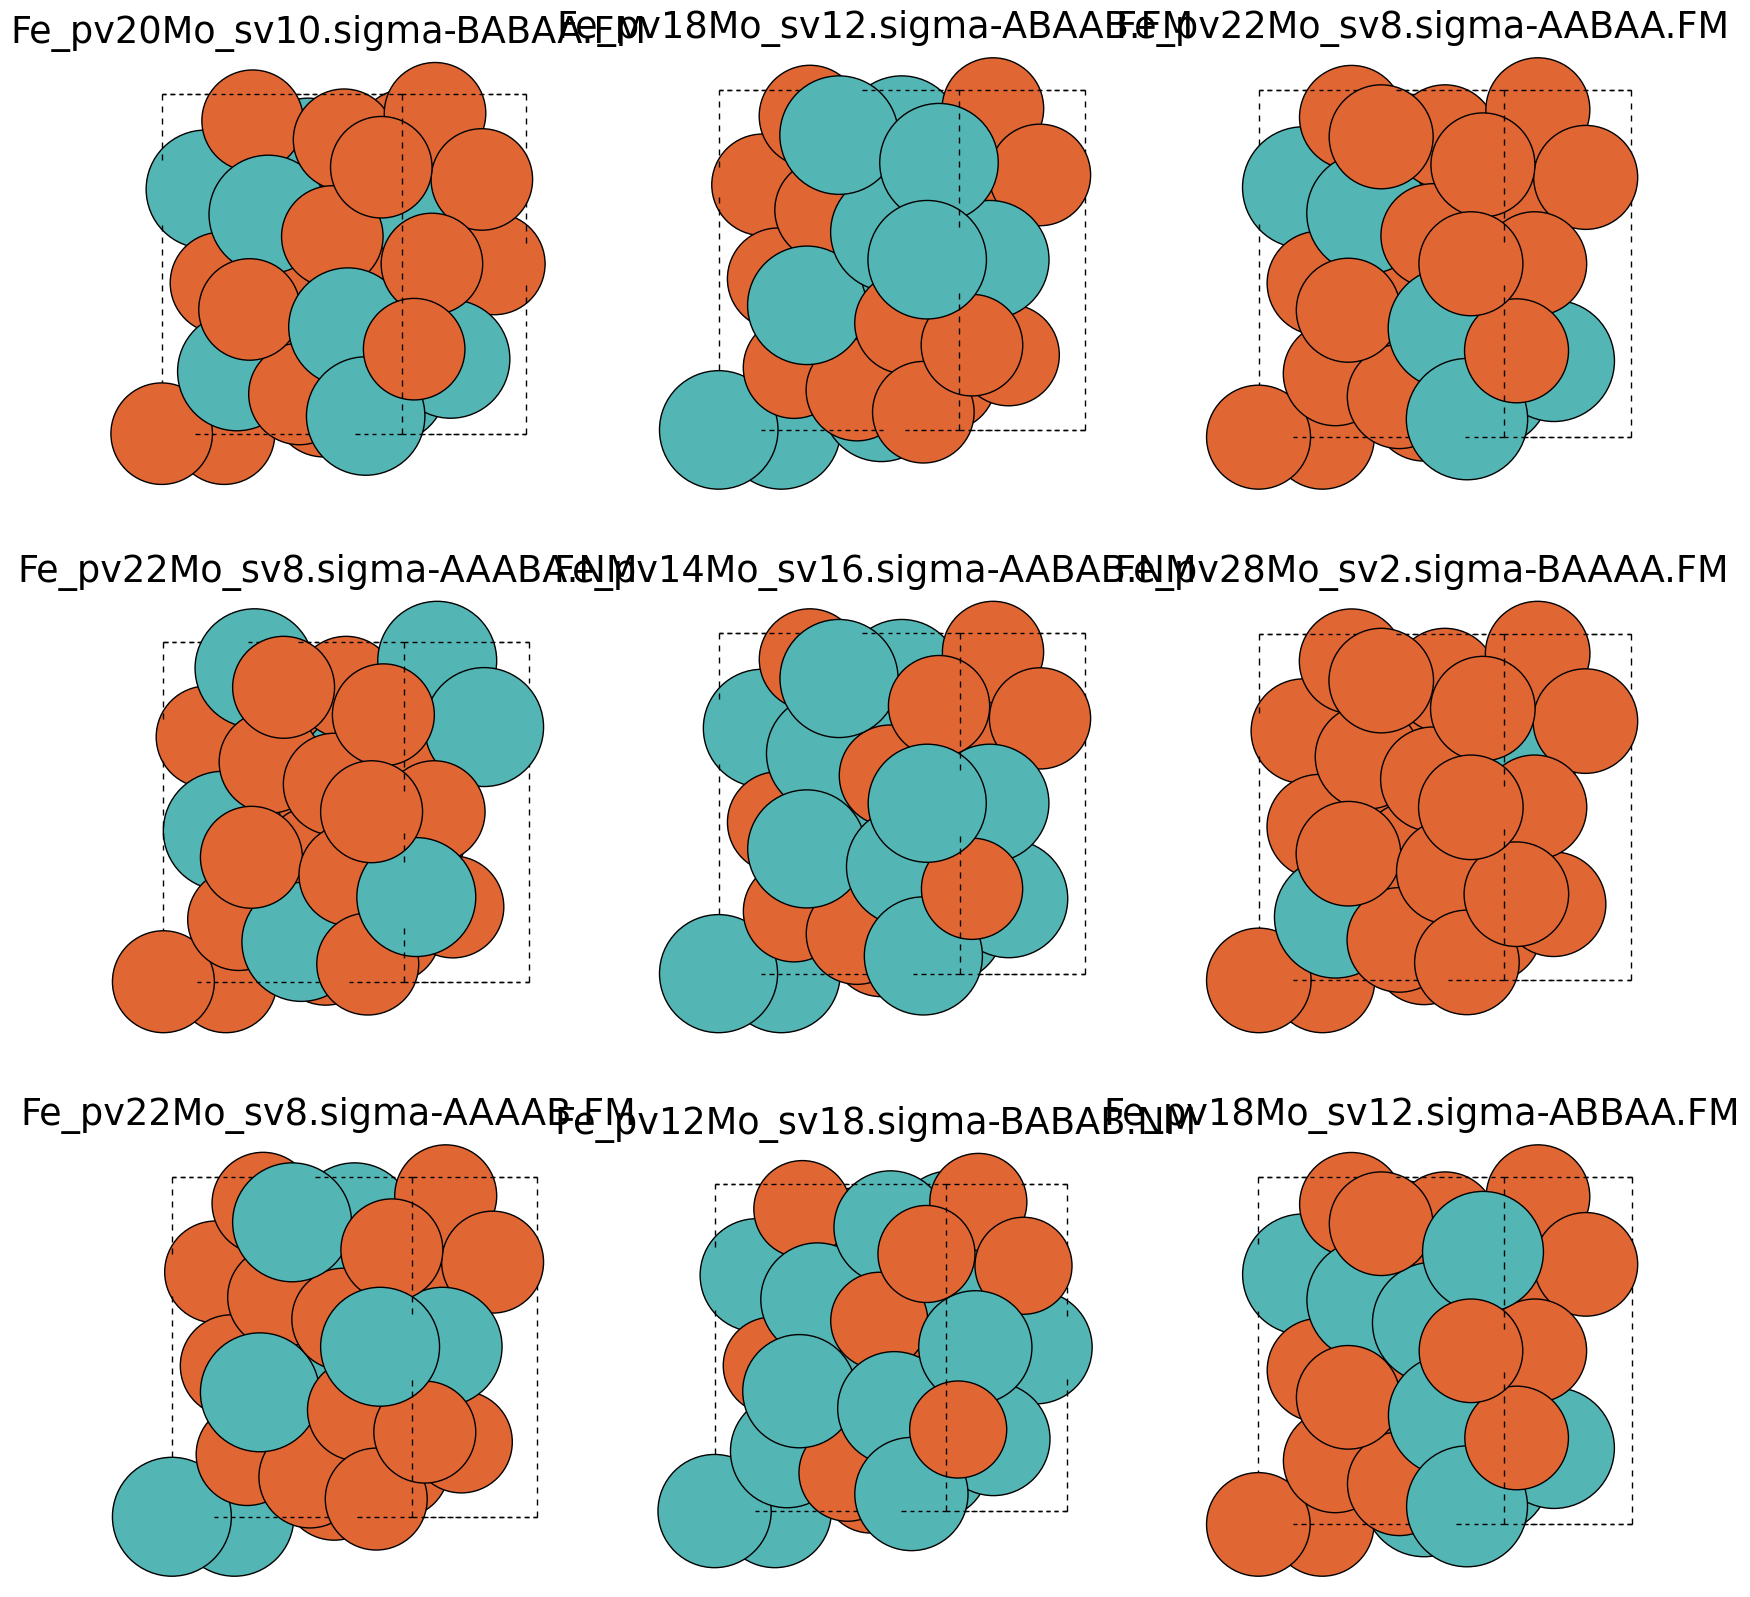

In [21]:
atoms_samples = Atoms_Objects.atoms.sample(n=9)
fig, ax = plt.subplots(3,3, figsize = (20,20))
ax = ax.flatten()
for thisax, (thisname, thisatoms) in  zip(ax, somesigmas.iteritems()):
    plot_atoms(thisatoms, ax=thisax, rotation='90y, 90x, 45y')
    [spine.set_visible(False) for spine in thisax.spines.values()]
    thisax.set_xticks([])
    thisax.set_yticks([])
    thisax.set_title(thisname)

 For the actual visualization of the structures, we should choose one example for each structure and then draw in Vesta or Ovito for good quality figures, including coordination polyhedra etc.

# Curate Dataset to available structures 

There are still some R structures not available in data but present in briefsummaries

In [22]:
Problems = BS.index.difference(Atoms_Objects.index)

In [23]:
BS.loc[Problems]

,,V,E0,B,fit,xc,encut,deltak,ncrash,nelem,...,V0,atom_A,atom_B,num_atom_A,num_atom_B,num_atoms,Fe_pv,Mo_sv,EF,Phase


In [24]:
GoodBS = BS.loc[Atoms_Objects.index]

In [25]:
GoodBS

,,V,E0,B,fit,xc,encut,deltak,ncrash,nelem,...,V0,atom_A,atom_B,num_atom_A,num_atom_B,num_atoms,Fe_pv,Mo_sv,EF,Phase
Fe_pv8.A15.FM,bulk A15.FM,11.558019 A,-8.169759,91.497861 GPa,murnaghan volume_relaxed,PBE-PAW,450,0.020,0,1,...,11.558019,Fe_pv,,8,0,8,1.000000,0.000000,0.085535,A15
Fe_pv12.C14.FM,bulk C14.FM,12.119019 A,-8.105991,102.152576 GPa,murnaghan volume_relaxed,PBE-PAW,450,0.020,0,1,...,12.119019,Fe_pv,,12,0,12,1.000000,0.000000,0.149303,C14
Fe_pv17Mo_sv12.chi-AAAB.FM,bulk chi-AAAB.FM,13.726541 A,-9.026366,122.743390 GPa,murnaghan volume_relaxed,PBE-PAW,450,0.020,0,2,...,13.726541,Fe_pv,Mo_sv,17,12,29,0.586207,0.413793,0.337462,chi
Fe_pv24Mo_sv5.chi-BBAA.FM,bulk chi-BBAA.FM,11.926180 A,-8.658669,124.301732 GPa,murnaghan volume_relaxed,PBE-PAW,450,0.020,0,2,...,11.926180,Fe_pv,Mo_sv,24,5,29,0.827586,0.172414,0.058514,chi
Fe_pv25Mo_sv4.chi-ABAA.FM,bulk chi-ABAA.FM,11.874474 A,-8.560894,134.837320 GPa,murnaghan volume_relaxed,PBE-PAW,450,0.020,0,2,...,11.874474,Fe_pv,Mo_sv,25,4,29,0.862069,0.137931,0.063911,chi
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
Fe_pv25Mo_sv4.chi-ABAA.NM,bulk chi-ABAA,11.072302 A,-8.505552,279.868523 GPa,murnaghan volume_relaxed,PBE-PAW,450,0.020,0,2,...,11.072302,Fe_pv,Mo_sv,25,4,29,0.862069,0.137931,0.057857,chi
Fe_pv16Mo_sv8.C36-BBAAA.NM,bulk C36-BBAAA,12.044661 A,-9.117739,281.820517 GPa,murnaghan volume_relaxed,PBE-PAW,450,0.020,0,2,...,12.044661,Fe_pv,Mo_sv,16,8,24,0.666667,0.333333,-0.016932,C36
Fe_pv8Mo_sv4.C14-BAA.NM,bulk C14-BAA,12.031891 A,-9.133101,282.397960 GPa,murnaghan volume_relaxed,PBE-PAW,450,0.020,0,2,...,12.031891,Fe_pv,Mo_sv,8,4,12,0.666667,0.333333,-0.032294,C14
Fe_pv4.fcc-cubic.NM,bulk fcc-cubic,10.248696 A,-8.104999,283.740438 GPa,murnaghan volume_relaxed,PBE-PAW,450,0.020,0,1,...,10.248696,Fe_pv,,4,0,4,1.000000,0.000000,0.079070,fcc


In [26]:
FullyCuratedBSFile = os.path.join(dataset,'FullyCuratedParsedBriefSummary.pkl')

In [27]:
GoodBS.to_pickle(FullyCuratedBSFile)

#  Final Distributions of targets

In [28]:
plt.rc('axes.spines', bottom=True, top=True, right=True, left=True)

<AxesSubplot:xlabel='B0', ylabel='Count'>

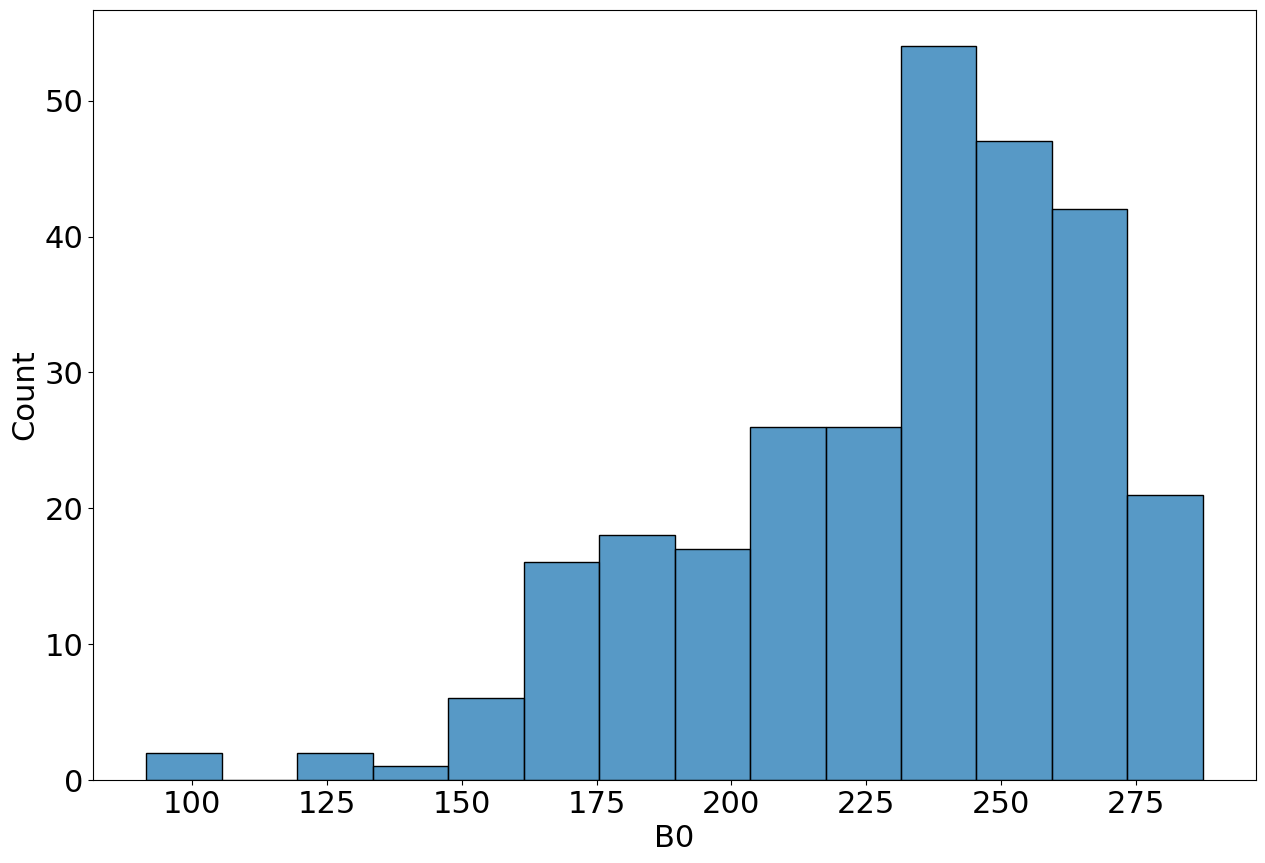

In [29]:
sns.histplot(BS['B0'])

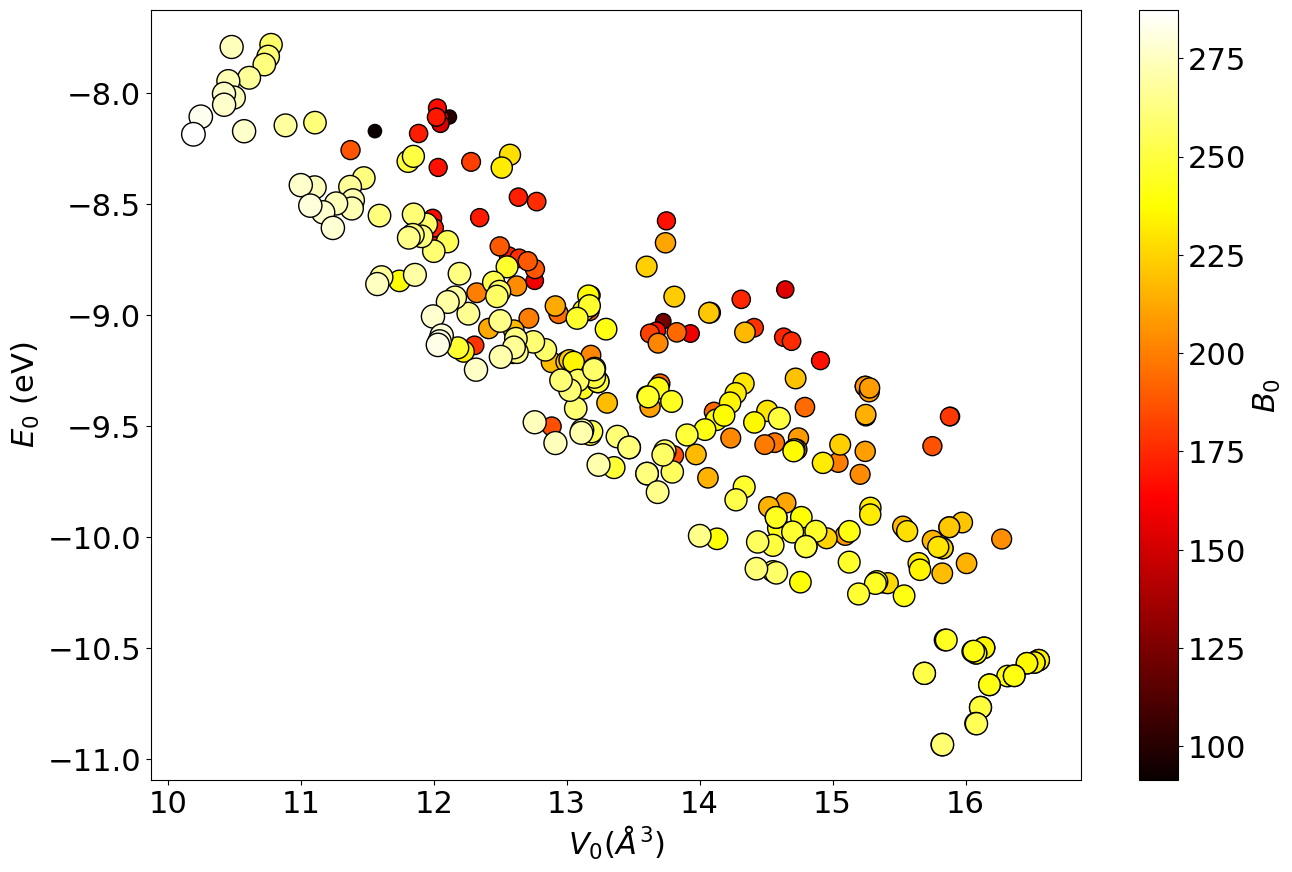

In [30]:
#fig, ax = plt.subplots()
plt.scatter(BS.V0, BS.E0, c=BS.B0, marker = 'o' , s = BS.B0, cmap='hot', edgecolor='k')
cbar = plt.colorbar()
plt.ylabel(r'$E_0$ (eV)')
plt.xlabel(r'$V_0 (\AA^3)$')
cbar.set_label(r'$B_0$')
#outlier_left =BS[(BS['E0']<-10) & (BS['V0']<11)].index
#plt.annotate(outlier_left[0],*BS.loc[outlier_left][['V0', 'E0']].values, fontsize=16 )

In [31]:
volumes = Atoms_Objects['atoms'].map(lambda a: a.get_volume())/BS['num_atoms']

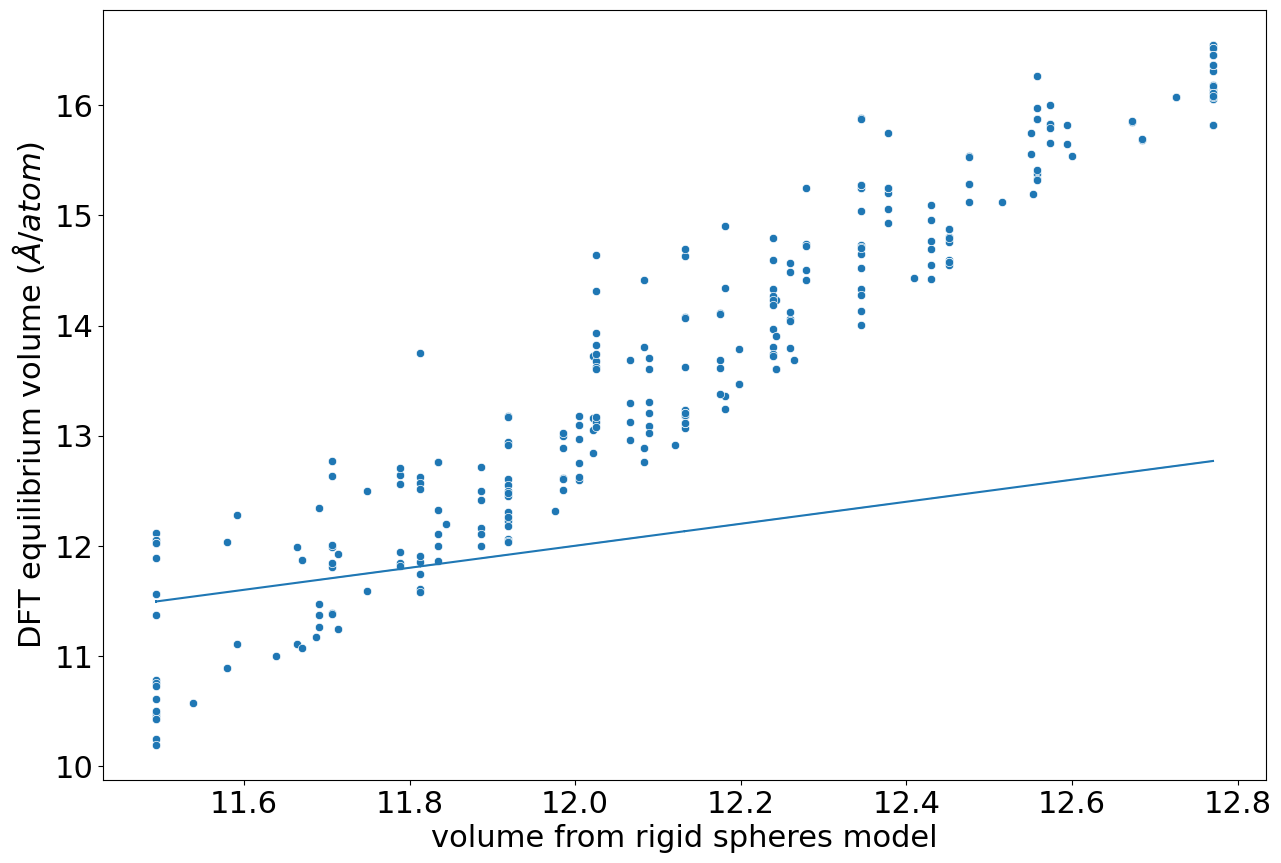

In [32]:
ax  = sns.scatterplot(volumes, BS['V0'])
ax = sns.lineplot(volumes, volumes, ax = ax)
ax.set_ylabel('DFT equilibrium volume ($ \AA /atom $)')
ax.set_xlabel('volume from rigid spheres model')
plt.ion()